# Explainable & Uncertainty-Aware DL for ALL Detection from Blood Smear Images

**Binary classification:** ALL / leukemic blast cells vs. Normal / healthy cells.

This notebook implements a leakage-aware, explainable, uncertainty-aware, calibration-based
**internal-validation** framework comparing modern CNN and Vision Transformer models, designed
for a publishable medical-AI study (no external validation — treated explicitly as a limitation).

**Designed for:** Google Colab + A100 GPU, dataset as a `.zip` in Google Drive (~15,135 images,
e.g. the C-NMC 2019 ALL dataset where patient IDs are encoded in filenames).

**Pipeline:** setup & reproducibility -> Drive mount & extract -> dataset audit (duplicates,
corrupt, quality) -> subject-level / stratified split -> dataloaders -> model zoo (timm) ->
training (AMP, AdamW, scheduler, early stopping, class-weights / focal loss) -> full metric suite
-> Grad-CAM explainability -> uncertainty (TTA / MC-dropout) -> calibration (ECE, reliability,
temperature scaling) -> failure analysis -> ablation -> statistics (bootstrap CIs, McNemar) ->
results export.

> Edit the `CONFIG` cell, then run top-to-bottom. Set `QUICK_TEST=True` first to smoke-test the
> whole pipeline on a small subset before launching the full run.

## 1. Environment setup
Run once. Colab already ships PyTorch + CUDA; we add `timm`, `grad-cam`, `torchmetrics`,
`statsmodels`, `imagehash`, `seaborn`.

In [1]:
# === Install extra deps (run once per session) ===
!pip -q install timm grad-cam torchmetrics statsmodels imagehash seaborn --upgrade
print("Done. If timm/torch were upgraded, restart the runtime, then re-run from here.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 130.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 33.3 MB/s eta 0:00:00
Done. If timm/torch were upgraded, restart the runtime, then re-run from here.


In [2]:
# === Imports ===
import os, re, gc, json, time, math, random, hashlib, zipfile, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = False  # we WANT to detect truncated/corrupt images

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
from sklearn.model_selection import StratifiedGroupKFold, StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, cohen_kappa_score,
                             matthews_corrcoef, confusion_matrix, roc_curve,
                             precision_recall_curve, brier_score_loss)

warnings.filterwarnings("ignore")
sns.set_context("talk"); sns.set_style("whitegrid")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch:", torch.__version__, "| timm:", timm.__version__, "| device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128 | timm: 1.0.27 | device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Reproducibility
Fixed seed + deterministic flags. `seed_worker` keeps DataLoader workers reproducible.

In [3]:
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    s = SEED + worker_id
    np.random.seed(s); random.seed(s)

g = torch.Generator(); g.manual_seed(SEED)
seed_everything()
print("Seed fixed at", SEED)

Seed fixed at 42


## 3. Configuration
The single place to edit. `DATA_ROOT` is filled automatically after extraction in section 4.

In [40]:
CONFIG = {
    # --- paths ---
    "DRIVE_ZIP_PATH": "/content/drive/MyDrive/C-NMC_Leukemia.zip",  # <-- your zip in Drive
    "EXTRACT_DIR":    "/content/all_data",                        # local SSD extraction target
    "OUTPUT_DIR":     "/content/drive/MyDrive/ALL_results",       # save tables/figures/models here

    # --- class semantics ---
    # Positive class = disease (ALL). Folder/filename tokens used to infer labels.
    "POSITIVE_TOKENS": ["all", "leukemia", "blast", "malignant", "cancer"],
    "NEGATIVE_TOKENS": ["hem", "normal", "healthy", "benign"],
    "CLASS_NAMES": ["Normal", "ALL"],   # index 0, 1

    # --- image / training ---
    "IMG_SIZE": 224,
    "BATCH_SIZE": 64,            # A100 can handle this for 224px / tiny ViTs
    "NUM_WORKERS": 4,
    "EPOCHS": 25,
    "PATIENCE": 7,              # early-stopping patience (epochs)
    "LR": 3e-4,
    "WEIGHT_DECAY": 1e-4,
    "SCHEDULER": "onecycle",   # "onecycle" or "cosine"
    "LABEL_SMOOTHING": 0.0,
    "DROP_RATE": 0.2,          # enables MC-dropout uncertainty
    "USE_AMP": True,
    "MONITOR": "val_auc",      # early-stopping/checkpoint metric: "val_auc" or "val_loss"

    # --- loss & imbalance ---
    "LOSS": "weighted_ce",     # "ce" | "weighted_ce" | "focal"
    "FOCAL_GAMMA": 2.0,

    # --- split ---
    "TEST_FRAC": 0.15,
    "VAL_FRAC": 0.15,          # of the full set; train = rest
    "USE_CV": True,           # 5-fold CV on dev (train+val) set
    "CV_FOLDS": 5,

    # --- model zoo (timm names) ---
    "ALL_MODELS": {
        "ResNet50":        "resnet50",
        "DenseNet121":     "densenet121",
        "EfficientNetV2-S":"tf_efficientnetv2_s",
        "ConvNeXt-Tiny":   "convnext_tiny",
        "Swin-Tiny":       "swin_tiny_patch4_window7_224",
        "MaxViT-Tiny":     "maxvit_tiny_tf_224",
        "MobileNetV3-L":   "mobilenetv3_large_100",
    },
    # Trim this list for shorter runs. Baselines: ResNet50, DenseNet121, MobileNetV3-L.
    "MODELS_TO_RUN": ["ResNet50", "DenseNet121", "EfficientNetV2-S",
                       "ConvNeXt-Tiny", "Swin-Tiny", "MobileNetV3-L"],

    # --- analysis toggles ---
    "TTA_PASSES": 10,          # test-time augmentation passes for uncertainty
    "MC_PASSES": 20,           # Monte-Carlo dropout passes
    "BOOTSTRAP_N": 2000,       # bootstrap resamples for CIs

    # --- smoke test ---
    "QUICK_TEST": False,        # True -> subset data + 2 epochs to validate the pipeline
    "QUICK_TEST_PER_CLASS": 300,
    "QUICK_TEST_EPOCHS": 2,
}

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
print(json.dumps({k: v for k, v in CONFIG.items() if k != "ALL_MODELS"}, indent=2, default=str))

{
  "DRIVE_ZIP_PATH": "/content/drive/MyDrive/C-NMC_Leukemia.zip",
  "EXTRACT_DIR": "/content/all_data",
  "OUTPUT_DIR": "/content/drive/MyDrive/ALL_results",
  "POSITIVE_TOKENS": [
    "all",
    "leukemia",
    "blast",
    "malignant",
    "cancer"
  ],
  "NEGATIVE_TOKENS": [
    "hem",
    "normal",
    "healthy",
    "benign"
  ],
  "CLASS_NAMES": [
    "Normal",
    "ALL"
  ],
  "IMG_SIZE": 224,
  "BATCH_SIZE": 64,
  "NUM_WORKERS": 4,
  "EPOCHS": 25,
  "PATIENCE": 7,
  "LR": 0.0003,
  "WEIGHT_DECAY": 0.0001,
  "SCHEDULER": "onecycle",
  "LABEL_SMOOTHING": 0.0,
  "DROP_RATE": 0.2,
  "USE_AMP": true,
  "MONITOR": "val_auc",
  "LOSS": "weighted_ce",
  "FOCAL_GAMMA": 2.0,
  "TEST_FRAC": 0.15,
  "VAL_FRAC": 0.15,
  "USE_CV": true,
  "CV_FOLDS": 5,
  "MODELS_TO_RUN": [
    "ResNet50",
    "DenseNet121",
    "EfficientNetV2-S",
    "ConvNeXt-Tiny",
    "Swin-Tiny",
    "MobileNetV3-L"
  ],
  "TTA_PASSES": 10,
  "MC_PASSES": 20,
  "BOOTSTRAP_N": 2000,
  "QUICK_TEST": false,
  "QUICK_TEST

## 4. Mount Drive & extract the dataset
Extraction goes to local Colab SSD (`/content/...`) — far faster I/O than reading from Drive.

In [9]:
from google.colab import drive
import os
import shutil # Import shutil for rmtree

def mount_drive(mount_point="/content/drive"):
    # Ensure the mount point directory exists
    os.makedirs(mount_point, exist_ok=True)

    # Check if the mount point contains files and clear them
    # This specifically addresses the ValueError: Mountpoint must not already contain files
    if os.path.exists(mount_point) and os.listdir(mount_point):
        print(f"Mount point {mount_point} contains files. Attempting to clear it...")
        try:
            # First, try to unmount gracefully, though it might not be a Colab mount
            drive.flush_and_unmount()
            print("Colab Drive unmounted (if previously mounted).")
        except Exception:
            print("No active Colab Drive mount to unmount or unmount failed.")
            pass # Ignore if there was no active mount or unmount failed

        try:
            # Forcefully remove all contents of the directory
            shutil.rmtree(mount_point)
            # Recreate the empty directory
            os.makedirs(mount_point)
            print(f"Mount point {mount_point} successfully cleared.")
        except Exception as e:
            print(f"WARNING: Failed to clear mount point {mount_point}: {e}")
            print("This might cause 'Mountpoint must not already contain files' error.")
            # If clearing fails, the subsequent mount might still fail.

    # Now attempt to mount Google Drive
    try:
        print(f"Attempting to mount Google Drive at {mount_point} with force_remount=True.")
        drive.mount(mount_point, force_remount=True)
    except Exception as e:
        print(f"ERROR: Drive mount failed: {repr(e)}")
        print("Please check permissions, your internet connection, or restart the Colab runtime and try again.")

    ok = os.path.exists(os.path.join(mount_point, "MyDrive"))
    print("Drive mounted:", ok)
    if not ok:
        print("If the auth popup timed out or connection issues occurred: Runtime > Restart session, then re-run this cell.")
    return ok

mount_drive()

Mount point /content/drive contains files. Attempting to clear it...
Colab Drive unmounted (if previously mounted).
This might cause 'Mountpoint must not already contain files' error.
Attempting to mount Google Drive at /content/drive with force_remount=True.
Mounted at /content/drive
Drive mounted: True


True

In [22]:
def extract_zip(zip_path, out_dir):
    if not os.path.exists(zip_path):
        # help the user find the right path instead of a bare FileNotFoundError
        mydrive = "/content/drive/MyDrive"
        print(f"[ERROR] Zip not found at: {zip_path}")
        if os.path.exists(mydrive):
            print("\nTop-level items in your Drive (MyDrive):")
            for n in sorted(os.listdir(mydrive))[:40]:
                tag = "/" if os.path.isdir(os.path.join(mydrive, n)) else ""
                print("  ", n + tag)
            zips = []
            for r, _, files in os.walk(mydrive):
                for f in files:
                    if f.lower().endswith(".zip"):
                        zips.append(os.path.join(r, f))
            if zips:
                print("\n.zip files found in your Drive:")
                for z in zips[:20]: print("  ", z)
                print("\n-> Copy the correct path into CONFIG['DRIVE_ZIP_PATH'] and re-run.")
        raise FileNotFoundError(zip_path)

    out = Path(out_dir)
    if out.exists() and any(out.rglob("*")):
        print("Extract dir already populated, skipping unzip:", out_dir)
        return out_dir
    out.mkdir(parents=True, exist_ok=True)
    print("Extracting", zip_path, "->", out_dir)
    t0 = time.time()
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(out_dir)
    print(f"Extracted in {time.time()-t0:.1f}s")
    return out_dir

extract_zip(CONFIG["DRIVE_ZIP_PATH"], CONFIG["EXTRACT_DIR"])
CONFIG["DATA_ROOT"] = CONFIG["EXTRACT_DIR"]

Extract dir already populated, skipping unzip: /content/all_data


## 5. Dataset structure discovery
We walk the extracted tree, list image files, and infer each image's **class** and **patient ID**.

Label inference order: (1) tokens in the filename, then (2) tokens in the parent-folder names.
Patient-ID parsing tries common C-NMC patterns (e.g. `UID_H10_...`, `UID_1_...`); if it fails for
most images, we fall back to **image-level** splitting and flag it as a limitation.

In [23]:
IMG_EXTS = {".bmp", ".png", ".jpg", ".jpeg", ".tif", ".tiff"}

def _tokens(s):
    # split on any non-alphanumeric so "UID_1_1_all" -> {uid,1,all}
    return set(t for t in re.split(r"[^a-z0-9]+", s.lower()) if t)

def infer_label(path):
    p = Path(path)
    # ONLY filename stem + immediate parent folder. Looking at the full ancestor
    # path lets root dirs like "all_data" or "C-NMC_Leukemia" inject class tokens
    # into every image, which silently drops the negative class.
    cand = _tokens(p.stem) | _tokens(p.parent.name)
    pos = any(t in cand for t in CONFIG["POSITIVE_TOKENS"])
    neg = any(t in cand for t in CONFIG["NEGATIVE_TOKENS"])
    if pos and not neg: return 1
    if neg and not pos: return 0
    return -1  # ambiguous

PID_PATTERNS = [
    re.compile(r"UID_(H?\d+)_", re.I),     # keep the H: H10 (healthy) != 10 (ALL)
    re.compile(r"patient[_-]?(\d+)", re.I),
    re.compile(r"\bP(\d+)\b", re.I),
]

def infer_patient_id(path):
    name = Path(path).name
    for pat in PID_PATTERNS:
        m = pat.search(name)
        if m:
            return f"pid_{m.group(1).upper()}"
    for par in Path(path).parents:
        m = re.fullmatch(r"(?:patient[_-]?)?(\d+)", par.name, re.I)
        if m:
            return f"pid_{m.group(1)}"
    return None

def build_inventory(root):
    rows = []
    for p in Path(root).rglob("*"):
        if p.suffix.lower() in IMG_EXTS and p.is_file():
            rows.append({"filepath": str(p), "label": infer_label(p),
                         "patient_id": infer_patient_id(p)})
    return pd.DataFrame(rows)

df = build_inventory(CONFIG["DATA_ROOT"])
print("Total image files found:", len(df))
print("\nLabel inference:")
print(df["label"].map({0: "Normal", 1: "ALL", -1: "AMBIGUOUS"}).value_counts())

amb = (df["label"] == -1).sum()
if amb:
    print(f"\n[WARN] {amb} images could not be labelled. Inspect a few:")
    print(df[df.label == -1]["filepath"].head(10).tolist())
    print("-> Adjust POSITIVE_TOKENS / NEGATIVE_TOKENS in CONFIG, then re-run section 5.")

df = df[df.label != -1].reset_index(drop=True)

# sanity: both classes must be present before we go any further
assert df["label"].nunique() == 2, (
    "Only one class present after labelling. Check POSITIVE_TOKENS/NEGATIVE_TOKENS "
    "and your folder/filename layout.")

HAS_PID = df["patient_id"].notna().mean() > 0.8
print(f"\nPatient IDs parsed for {df['patient_id'].notna().mean()*100:.1f}% of images.")
print("Splitting strategy:", "SUBJECT-LEVEL (grouped)" if HAS_PID else "IMAGE-LEVEL stratified (LIMITATION)")
if not HAS_PID:
    df["patient_id"] = [f"img_{i}" for i in range(len(df))]  # each image its own group

Total image files found: 30228

Label inference:
label
ALL          14544
AMBIGUOUS     8906
Normal        6778
Name: count, dtype: int64

[WARN] 8906 images could not be labelled. Inspect a few:
['/content/all_data/__MACOSX/C-NMC_Leukemia/testing_data/C-NMC_test_final_phase_data/._289.bmp', '/content/all_data/__MACOSX/C-NMC_Leukemia/testing_data/C-NMC_test_final_phase_data/._1725.bmp', '/content/all_data/__MACOSX/C-NMC_Leukemia/testing_data/C-NMC_test_final_phase_data/._1114.bmp', '/content/all_data/__MACOSX/C-NMC_Leukemia/testing_data/C-NMC_test_final_phase_data/._2550.bmp', '/content/all_data/__MACOSX/C-NMC_Leukemia/testing_data/C-NMC_test_final_phase_data/._2371.bmp', '/content/all_data/__MACOSX/C-NMC_Leukemia/testing_data/C-NMC_test_final_phase_data/._978.bmp', '/content/all_data/__MACOSX/C-NMC_Leukemia/testing_data/C-NMC_test_final_phase_data/._285.bmp', '/content/all_data/__MACOSX/C-NMC_Leukemia/testing_data/C-NMC_test_final_phase_data/._402.bmp', '/content/all_data/__MACOSX/C-N

## 6. Data audit: corrupt images, duplicates, quality
- **Corrupt:** fully decode each image; drop unreadable ones.
- **Duplicates:** perceptual hash (`imagehash.phash`); near-duplicates that land in different
  splits are a subtle leakage source, so we drop duplicate copies (keep first).
- **Quality:** brightness (mean intensity) and sharpness (variance of Laplacian) summary stats.

In [24]:
import imagehash
from PIL import ImageFilter

def laplacian_var(gray_arr):
    # cheap sharpness proxy without OpenCV
    k = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32)
    a = gray_arr.astype(np.float32)
    lap = (a[:-2,1:-1]+a[2:,1:-1]+a[1:-1,:-2]+a[1:-1,2:]-4*a[1:-1,1:-1])
    return float(lap.var())

def audit(df, sample_quality=True):
    corrupt, phashes, brightness, sharp = [], [], [], []
    keep = np.ones(len(df), dtype=bool)
    for i, fp in enumerate(df["filepath"]):
        try:
            with Image.open(fp) as im:
                im = im.convert("RGB")
                phashes.append(str(imagehash.phash(im)))
                if sample_quality:
                    small = im.resize((128,128))
                    arr = np.asarray(small.convert("L"))
                    brightness.append(float(arr.mean()))
                    sharp.append(laplacian_var(arr))
        except Exception as e:
            corrupt.append(fp); keep[i] = False; phashes.append(None)
            if sample_quality: brightness.append(np.nan); sharp.append(np.nan)
        if (i+1) % 2000 == 0:
            print(f"  audited {i+1}/{len(df)}")
    df = df.copy()
    df["phash"] = phashes
    if sample_quality:
        df["brightness"] = brightness; df["sharpness"] = sharp
    df = df[keep].reset_index(drop=True)
    return df, corrupt

df, corrupt = audit(df)
print(f"\nCorrupt/unreadable images dropped: {len(corrupt)}")

# duplicate handling (keep first occurrence of each perceptual hash)
dup_mask = df.duplicated(subset=["phash"], keep="first")
print(f"Exact perceptual-duplicate images dropped: {int(dup_mask.sum())}")
df = df[~dup_mask].reset_index(drop=True)

print("\nFinal usable images:", len(df))
print(df["label"].map({0:"Normal",1:"ALL"}).value_counts())
print("\nQuality summary:")
print(df[["brightness","sharpness"]].describe().round(2))

  audited 2000/21322
  audited 4000/21322
  audited 6000/21322
  audited 8000/21322
  audited 10000/21322
  audited 12000/21322
  audited 14000/21322
  audited 16000/21322
  audited 18000/21322
  audited 20000/21322

Corrupt/unreadable images dropped: 10661
Exact perceptual-duplicate images dropped: 688

Final usable images: 9973
label
ALL       6831
Normal    3142
Name: count, dtype: int64

Quality summary:
       brightness  sharpness
count     9973.00    9973.00
mean         7.86      91.30
std          2.67      26.51
min          1.44      24.93
25%          5.75      73.10
50%          7.65      86.28
75%          9.77     102.89
max         18.49     308.04


In [13]:
# Optional quick subset for smoke-testing the full pipeline end-to-end.
full_df = df.copy()
if CONFIG["QUICK_TEST"]:
    n = CONFIG["QUICK_TEST_PER_CLASS"]
    df = (full_df.groupby("label", group_keys=False)
                 .apply(lambda x: x.sample(min(n, len(x)), random_state=SEED))
                 .reset_index(drop=True))
    CONFIG["EPOCHS"] = CONFIG["QUICK_TEST_EPOCHS"]
    print(f"[QUICK_TEST] using {len(df)} images, {CONFIG['EPOCHS']} epochs.")
    print(df["label"].value_counts())

[QUICK_TEST] using 600 images, 2 epochs.
label
0    300
1    300
Name: count, dtype: int64


## 7. Class distribution & sample visualisation (Figures 1 & 2)

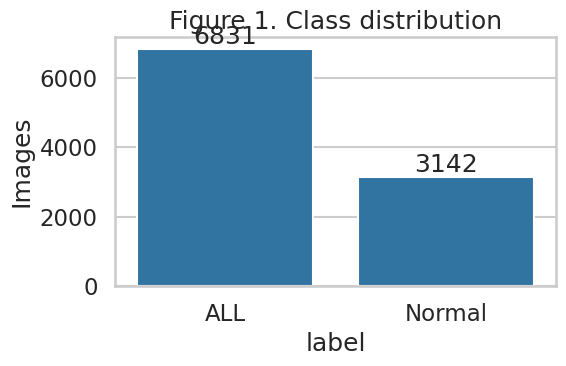

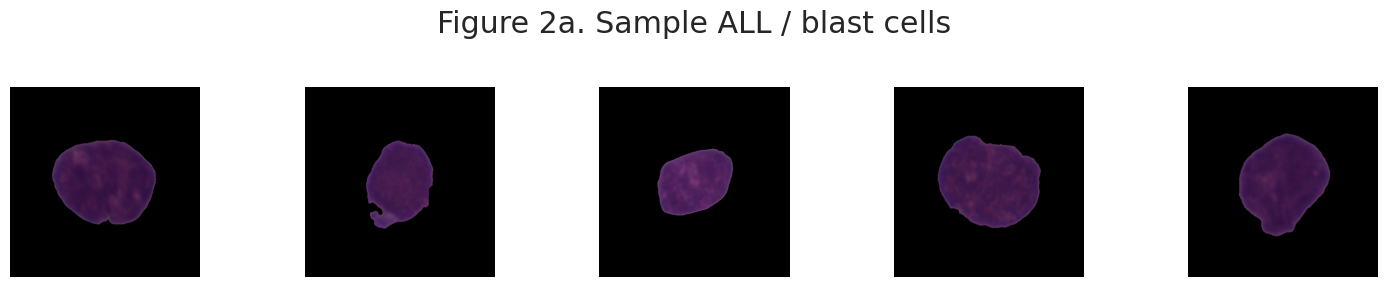

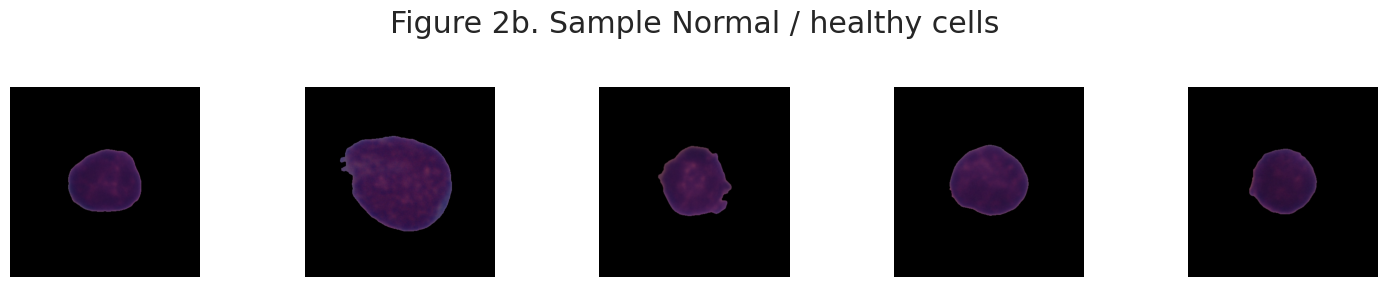

In [25]:
fig, ax = plt.subplots(figsize=(6,4))
counts = df["label"].map({0:"Normal",1:"ALL"}).value_counts()
sns.barplot(x=counts.index, y=counts.values, ax=ax)
ax.set_title("Figure 1. Class distribution"); ax.set_ylabel("Images")
for i,v in enumerate(counts.values): ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout(); plt.savefig(f"{CONFIG['OUTPUT_DIR']}/fig1_class_distribution.png", dpi=150); plt.show()

def show_samples(df, label, k=5, title=""):
    sub = df[df.label==label].sample(min(k,(df.label==label).sum()), random_state=SEED)
    fig, axs = plt.subplots(1, len(sub), figsize=(3*len(sub),3))
    if len(sub)==1: axs=[axs]
    for ax, fp in zip(axs, sub.filepath):
        ax.imshow(Image.open(fp).convert("RGB")); ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_samples(df, 1, title="Figure 2a. Sample ALL / blast cells")
show_samples(df, 0, title="Figure 2b. Sample Normal / healthy cells")

## 8. Leakage-free split (subject-level when possible)
`StratifiedGroupKFold` keeps all images from one patient inside a single split while approximately
preserving class balance. We carve **test** and **val** folds out, leaving the rest as **train**.
A persistent split record (CSV) is written for reproducibility.

In [26]:
def make_splits(df):
    y = df["label"].values
    groups = df["patient_id"].values
    n = len(df)
    # number of folds so that ~one fold == TEST_FRAC
    k = max(3, round(1.0 / CONFIG["TEST_FRAC"]))
    sgkf = StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=SEED)
    folds = list(sgkf.split(np.zeros(n), y, groups))
    test_idx = folds[0][1]
    val_idx  = folds[1][1]
    train_idx = np.setdiff1d(np.arange(n), np.union1d(test_idx, val_idx))
    df = df.copy(); df["split"] = "train"
    df.loc[df.index[val_idx], "split"] = "val"
    df.loc[df.index[test_idx], "split"] = "test"
    return df

df = make_splits(df)

# integrity check: no patient appears in more than one split
leak = (df.groupby("patient_id")["split"].nunique() > 1).sum()
print("Patients spanning >1 split (should be 0 when PIDs exist):", int(leak))

print("\nSplit sizes:")
print(df.groupby(["split","label"]).size().unstack(fill_value=0)
        .rename(columns={0:"Normal",1:"ALL"}))

# guard: fail loudly if any split is single-class (would give nan AUC / specificity)
for s in ["train","val","test"]:
    nc = df[df.split==s]["label"].nunique()
    assert nc == 2, f"{s} split has only {nc} class. Fix labels/PIDs or reduce group imbalance."

split_record = df[["filepath","patient_id","label","split"]]
split_record.to_csv(f"{CONFIG['OUTPUT_DIR']}/split_record.csv", index=False)
print("\nSplit record saved -> split_record.csv")

train_df = df[df.split=="train"].reset_index(drop=True)
val_df   = df[df.split=="val"].reset_index(drop=True)
test_df  = df[df.split=="test"].reset_index(drop=True)

Patients spanning >1 split (should be 0 when PIDs exist): 0

Split sizes:
label  Normal   ALL
split              
test      207  1080
train    2622  4977
val       313   774

Split record saved -> split_record.csv


## 9. Transforms, Dataset, DataLoaders
Augmentations are **morphology-preserving**: flips, small rotations, mild colour jitter, gentle
random-resized-crop, occasional light blur. No heavy distortion that would corrupt nucleus /
cytoplasm structure.

In [27]:
SZ = CONFIG["IMG_SIZE"]

train_tf = T.Compose([
    T.Resize((int(SZ*1.14), int(SZ*1.14))),
    T.RandomResizedCrop(SZ, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(0.5),
    T.RandomVerticalFlip(0.5),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    T.RandomApply([T.GaussianBlur(3, sigma=(0.1, 1.0))], p=0.2),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = T.Compose([
    T.Resize((SZ, SZ)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# light TTA transform (used for uncertainty) -- stochastic but mild
tta_tf = T.Compose([
    T.Resize((int(SZ*1.08), int(SZ*1.08))),
    T.RandomCrop(SZ),
    T.RandomHorizontalFlip(0.5),
    T.RandomVerticalFlip(0.5),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CellDataset(Dataset):
    def __init__(self, frame, transform):
        self.fp = frame["filepath"].values
        self.y  = frame["label"].values.astype(np.int64)
        self.transform = transform
    def __len__(self): return len(self.fp)
    def __getitem__(self, i):
        img = Image.open(self.fp[i]).convert("RGB")
        return self.transform(img), self.y[i], i

def make_loader(frame, transform, shuffle, bs=None):
    bs = bs or CONFIG["BATCH_SIZE"]
    return DataLoader(CellDataset(frame, transform), batch_size=bs, shuffle=shuffle,
                      num_workers=CONFIG["NUM_WORKERS"], pin_memory=True,
                      worker_init_fn=seed_worker, generator=g, drop_last=False)

train_loader = make_loader(train_df, train_tf, shuffle=True)
val_loader   = make_loader(val_df,   eval_tf,  shuffle=False)
test_loader  = make_loader(test_df,  eval_tf,  shuffle=False)
print("Batches  train/val/test:", len(train_loader), len(val_loader), len(test_loader))

Batches  train/val/test: 119 17 21


## 10. Models, loss, optimiser, scheduler

| Model | Role | Why |
|---|---|---|
| ResNet50 | baseline | ubiquitous CNN reference for fair comparison |
| DenseNet121 | baseline | dense connectivity, strong on medical imaging |
| MobileNetV3-L | baseline (lightweight) | edge/deployment reference, params vs accuracy trade-off |
| EfficientNetV2-S | modern CNN | compound scaling, fast & accurate SOTA-class CNN |
| ConvNeXt-Tiny | modern CNN | transformer-inspired modern ConvNet |
| Swin-Tiny | transformer | hierarchical windowed attention, strong dense-prediction ViT |
| MaxViT-Tiny | transformer (opt.) | hybrid conv+block/grid attention |

All use ImageNet-pretrained weights via `timm` (transfer learning), `num_classes=2`,
`drop_rate` enabled for MC-dropout.

In [28]:
def build_model(timm_name):
    m = timm.create_model(timm_name, pretrained=True, num_classes=2,
                          drop_rate=CONFIG["DROP_RATE"])
    return m.to(DEVICE)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__(); self.gamma=gamma; self.weight=weight
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        return ((1-pt)**self.gamma * ce).mean()

def class_weights(frame):
    counts = np.bincount(frame["label"].values, minlength=2).astype(np.float32)
    w = counts.sum() / (2.0 * np.clip(counts, 1, None))
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)

def make_loss(frame, kind=None):
    kind = kind or CONFIG["LOSS"]
    w = class_weights(frame)
    if kind == "ce":
        return nn.CrossEntropyLoss(label_smoothing=CONFIG["LABEL_SMOOTHING"])
    if kind == "weighted_ce":
        return nn.CrossEntropyLoss(weight=w, label_smoothing=CONFIG["LABEL_SMOOTHING"])
    if kind == "focal":
        return FocalLoss(gamma=CONFIG["FOCAL_GAMMA"], weight=w)
    raise ValueError(kind)

def make_optim_sched(model, steps_per_epoch, epochs):
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["LR"],
                            weight_decay=CONFIG["WEIGHT_DECAY"])
    if CONFIG["SCHEDULER"] == "onecycle":
        sched = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=CONFIG["LR"], steps_per_epoch=steps_per_epoch, epochs=epochs)
        step_per_batch = True
    else:
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        step_per_batch = False
    return opt, sched, step_per_batch

## 11. Training loop (AMP + early stopping + best-checkpoint)

In [29]:
@torch.no_grad()
def collect_probs(model, loader, mc_dropout=False):
    if mc_dropout:
        model.train()  # keep dropout active
    else:
        model.eval()
    all_p, all_y = [], []
    for x, y, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=CONFIG["USE_AMP"]):
            logits = model(x)
        all_p.append(F.softmax(logits.float(), dim=1).cpu().numpy())
        all_y.append(y.numpy())
    return np.concatenate(all_p), np.concatenate(all_y)

def quick_val_metrics(model, loader, criterion):
    model.eval(); loss_sum=0; n=0; ps=[]; ys=[]
    with torch.no_grad():
        for x,y,_ in loader:
            x=x.to(DEVICE); y=y.to(DEVICE)
            with torch.amp.autocast("cuda", enabled=CONFIG["USE_AMP"]):
                logits=model(x); loss=criterion(logits,y)
            loss_sum+=loss.item()*len(y); n+=len(y)
            ps.append(F.softmax(logits.float(),1)[:,1].cpu().numpy()); ys.append(y.cpu().numpy())
    p=np.concatenate(ps); yt=np.concatenate(ys)
    try: auc=roc_auc_score(yt,p)
    except ValueError: auc=float("nan")
    return loss_sum/n, auc

def train_model(name, timm_name, train_frame, train_loader, val_loader,
                loss_kind=None, epochs=None, verbose=True):
    seed_everything()
    model = build_model(timm_name)
    epochs = epochs or CONFIG["EPOCHS"]
    criterion = make_loss(train_frame, loss_kind)
    opt, sched, step_per_batch = make_optim_sched(model, len(train_loader), epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=CONFIG["USE_AMP"])

    best = -np.inf if CONFIG["MONITOR"]=="val_auc" else np.inf
    best_state = None; bad = 0
    hist = {"train_loss":[], "val_loss":[], "val_auc":[]}

    for ep in range(epochs):
        model.train(); run=0; nb=0
        for x,y,_ in train_loader:
            x=x.to(DEVICE,non_blocking=True); y=y.to(DEVICE,non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=CONFIG["USE_AMP"]):
                logits=model(x); loss=criterion(logits,y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            if step_per_batch: sched.step()
            run+=loss.item(); nb+=1
        if not step_per_batch: sched.step()

        vloss, vauc = quick_val_metrics(model, val_loader, criterion)
        hist["train_loss"].append(run/max(nb,1)); hist["val_loss"].append(vloss); hist["val_auc"].append(vauc)
        cur = vauc if CONFIG["MONITOR"]=="val_auc" else vloss
        improved = cur > best if CONFIG["MONITOR"]=="val_auc" else cur < best
        if improved:
            best=cur; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; bad=0
        else:
            bad+=1
        if verbose:
            print(f"[{name}] ep{ep+1:02d}/{epochs} train_loss={run/max(nb,1):.4f} "
                  f"val_loss={vloss:.4f} val_auc={vauc:.4f}{'  *' if improved else ''}")
        if bad>=CONFIG["PATIENCE"]:
            if verbose: print(f"[{name}] early stop at epoch {ep+1}");
            break

    if best_state is not None: model.load_state_dict(best_state)
    return model, hist

## 12. Metric suite
Accuracy, precision, recall(sensitivity), specificity, F1, ROC-AUC, PR-AUC, Cohen's kappa,
MCC, Brier, ECE, plus efficiency (params, model size MB, inference ms/image).

**Why sensitivity & specificity matter clinically:** in leukemia *screening*, a missed ALL case
(false negative, low sensitivity) can delay life-critical treatment, while low specificity floods
haematologists with false alarms. Both must be reported, not just accuracy on an imbalanced set.

In [30]:
def expected_calibration_error(probs, labels, n_bins=15):
    conf = probs.max(1); pred = probs.argmax(1); acc = (pred==labels)
    bins = np.linspace(0,1,n_bins+1); ece=0.0
    for lo,hi in zip(bins[:-1],bins[1:]):
        m = (conf>lo)&(conf<=hi)
        if m.sum()>0:
            ece += (m.mean()) * abs(acc[m].mean() - conf[m].mean())
    return float(ece)

def specificity_score(y, pred):
    tn,fp,fn,tp = confusion_matrix(y,pred,labels=[0,1]).ravel()
    return tn/(tn+fp) if (tn+fp)>0 else float("nan")

def efficiency_stats(model, name):
    n_params = sum(p.numel() for p in model.parameters())
    tmp = f"/tmp/{name}.pt"; torch.save(model.state_dict(), tmp)
    size_mb = os.path.getsize(tmp)/1e6; os.remove(tmp)
    model.eval(); dummy = torch.randn(1,3,SZ,SZ,device=DEVICE)
    with torch.no_grad():
        for _ in range(5): _=model(dummy)  # warmup
        if DEVICE=="cuda": torch.cuda.synchronize()
        t0=time.time()
        for _ in range(50): _=model(dummy)
        if DEVICE=="cuda": torch.cuda.synchronize()
        ms = (time.time()-t0)/50*1000
    return n_params, size_mb, ms

def compute_metrics(probs, labels):
    p1 = probs[:,1]; pred = probs.argmax(1)
    try: auc=roc_auc_score(labels,p1)
    except ValueError: auc=float("nan")
    return {
        "accuracy":    accuracy_score(labels,pred),
        "precision":   precision_score(labels,pred,zero_division=0),
        "sensitivity": recall_score(labels,pred,zero_division=0),
        "specificity": specificity_score(labels,pred),
        "f1":          f1_score(labels,pred,zero_division=0),
        "roc_auc":     auc,
        "pr_auc":      average_precision_score(labels,p1),
        "kappa":       cohen_kappa_score(labels,pred),
        "mcc":         matthews_corrcoef(labels,pred),
        "brier":       brier_score_loss(labels,p1),
        "ece":         expected_calibration_error(probs,labels),
    }

## 13. Train all models & build the main comparison table (Table 3)
This is the heavy cell. Trim `CONFIG["MODELS_TO_RUN"]` for shorter runs. Trained models, histories,
and test predictions are cached in `RESULTS` for downstream explainability / calibration / stats.

In [31]:
RESULTS = {}  # name -> dict(model, hist, test_probs, test_labels, metrics, eff)

for name in CONFIG["MODELS_TO_RUN"]:
    timm_name = CONFIG["ALL_MODELS"][name]
    print("\n" + "="*70 + f"\nTraining {name} ({timm_name})\n" + "="*70)
    model, hist = train_model(name, timm_name, train_df, train_loader, val_loader)
    probs, labels = collect_probs(model, test_loader)
    metrics = compute_metrics(probs, labels)
    n_params, size_mb, ms = efficiency_stats(model, name)
    metrics.update({"params_M": n_params/1e6, "size_MB": size_mb, "infer_ms": ms})
    RESULTS[name] = {"model":model, "hist":hist, "test_probs":probs,
                     "test_labels":labels, "metrics":metrics}
    print(f"{name} test: AUC={metrics['roc_auc']:.4f} "
          f"Sens={metrics['sensitivity']:.4f} Spec={metrics['specificity']:.4f} "
          f"F1={metrics['f1']:.4f} ECE={metrics['ece']:.4f}")
    gc.collect(); torch.cuda.empty_cache()

main_table = pd.DataFrame({n: r["metrics"] for n,r in RESULTS.items()}).T
main_table = main_table.round(4)
main_table.to_csv(f"{CONFIG['OUTPUT_DIR']}/table3_model_comparison.csv")
print("\n=== Table 3. Main performance comparison ===")
display(main_table)

BEST_MODEL = main_table["roc_auc"].idxmax()
print("\nBest model by ROC-AUC:", BEST_MODEL)


Training ResNet50 (resnet50)
[ResNet50] ep01/25 train_loss=0.6663 val_loss=0.6349 val_auc=0.8225  *
[ResNet50] ep02/25 train_loss=0.5689 val_loss=0.5534 val_auc=0.8415  *
[ResNet50] ep03/25 train_loss=0.4330 val_loss=0.4795 val_auc=0.9157  *
[ResNet50] ep04/25 train_loss=0.3555 val_loss=0.3911 val_auc=0.9082
[ResNet50] ep05/25 train_loss=0.3159 val_loss=0.6855 val_auc=0.9374  *
[ResNet50] ep06/25 train_loss=0.2847 val_loss=0.7442 val_auc=0.9563  *
[ResNet50] ep07/25 train_loss=0.2637 val_loss=0.3462 val_auc=0.9103
[ResNet50] ep08/25 train_loss=0.2474 val_loss=0.5114 val_auc=0.8762
[ResNet50] ep09/25 train_loss=0.2340 val_loss=0.2788 val_auc=0.9538
[ResNet50] ep10/25 train_loss=0.2068 val_loss=0.3949 val_auc=0.9619  *
[ResNet50] ep11/25 train_loss=0.1907 val_loss=0.2707 val_auc=0.9453
[ResNet50] ep12/25 train_loss=0.1783 val_loss=0.5519 val_auc=0.9576
[ResNet50] ep13/25 train_loss=0.1710 val_loss=0.2236 val_auc=0.9580
[ResNet50] ep14/25 train_loss=0.1616 val_loss=1.1489 val_auc=0.9426


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

[Swin-Tiny] ep01/25 train_loss=0.5000 val_loss=0.3785 val_auc=0.9044  *
[Swin-Tiny] ep02/25 train_loss=0.3956 val_loss=0.3240 val_auc=0.9241  *
[Swin-Tiny] ep03/25 train_loss=0.3543 val_loss=0.2909 val_auc=0.9535  *
[Swin-Tiny] ep04/25 train_loss=0.3238 val_loss=0.2510 val_auc=0.9527
[Swin-Tiny] ep05/25 train_loss=0.3401 val_loss=0.3686 val_auc=0.9352
[Swin-Tiny] ep06/25 train_loss=0.3056 val_loss=0.3043 val_auc=0.9551  *
[Swin-Tiny] ep07/25 train_loss=0.3035 val_loss=0.4811 val_auc=0.9342
[Swin-Tiny] ep08/25 train_loss=0.2783 val_loss=0.2686 val_auc=0.9570  *
[Swin-Tiny] ep09/25 train_loss=0.2264 val_loss=0.1992 val_auc=0.9658  *
[Swin-Tiny] ep10/25 train_loss=0.2267 val_loss=0.3117 val_auc=0.9486
[Swin-Tiny] ep11/25 train_loss=0.2048 val_loss=0.2499 val_auc=0.9509
[Swin-Tiny] ep12/25 train_loss=0.1845 val_loss=0.2681 val_auc=0.9640
[Swin-Tiny] ep13/25 train_loss=0.1540 val_loss=0.2910 val_auc=0.9464
[Swin-Tiny] ep14/25 train_loss=0.1580 val_loss=0.1893 val_auc=0.9746  *
[Swin-Tiny] e

model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

[MobileNetV3-L] ep01/25 train_loss=1.5073 val_loss=0.8839 val_auc=0.7895  *
[MobileNetV3-L] ep02/25 train_loss=0.9076 val_loss=0.6366 val_auc=0.8208  *
[MobileNetV3-L] ep03/25 train_loss=0.6923 val_loss=0.6964 val_auc=0.8419  *
[MobileNetV3-L] ep04/25 train_loss=0.5575 val_loss=0.4656 val_auc=0.8525  *
[MobileNetV3-L] ep05/25 train_loss=0.5066 val_loss=0.4224 val_auc=0.8800  *
[MobileNetV3-L] ep06/25 train_loss=0.4724 val_loss=0.7210 val_auc=0.8245
[MobileNetV3-L] ep07/25 train_loss=0.4348 val_loss=0.4360 val_auc=0.9188  *
[MobileNetV3-L] ep08/25 train_loss=0.3787 val_loss=nan val_auc=nan
[MobileNetV3-L] ep09/25 train_loss=0.3774 val_loss=1952.1553 val_auc=0.5045
[MobileNetV3-L] ep10/25 train_loss=0.3254 val_loss=791.2603 val_auc=0.5729
[MobileNetV3-L] ep11/25 train_loss=0.2953 val_loss=0.4705 val_auc=0.9231  *
[MobileNetV3-L] ep12/25 train_loss=0.3043 val_loss=0.6800 val_auc=0.7490
[MobileNetV3-L] ep13/25 train_loss=0.2628 val_loss=0.2532 val_auc=0.9568  *
[MobileNetV3-L] ep14/25 trai

,accuracy,precision,sensitivity,specificity,f1,roc_auc,pr_auc,kappa,mcc,brier,ece,params_M,size_MB,infer_ms
ResNet50,0.8376,0.9698,0.8324,0.8647,0.8959,0.9239,0.9819,0.5368,0.5706,0.1237,0.0705,23.5121,94.3693,7.0804
DenseNet121,0.8811,0.9649,0.8907,0.8309,0.9263,0.9426,0.9869,0.6210,0.6346,0.0868,0.0256,6.9559,28.4403,18.5725
EfficientNetV2-S,0.9021,0.9578,0.9241,0.7874,0.9406,0.9310,0.9833,0.6624,0.6658,0.0780,0.0507,20.1800,81.6189,19.2957
ConvNeXt-Tiny,0.9052,0.9493,0.9370,0.7391,0.9432,0.9222,0.9813,0.6582,0.6587,0.0748,0.0380,27.8217,111.3580,6.4588
Swin-Tiny,0.8788,0.9743,0.8787,0.8792,0.9241,0.9321,0.9828,0.6280,0.6490,0.1008,0.0748,27.5209,110.1515,11.9980
MobileNetV3-L,0.8881,0.9517,0.9130,0.7585,0.9319,0.9160,0.9783,0.6183,0.6225,0.0887,0.0504,4.2046,17.0251,7.1072



Best model by ROC-AUC: DenseNet121


## 14. Training curves, confusion matrices, ROC & PR (Figures 4–7)

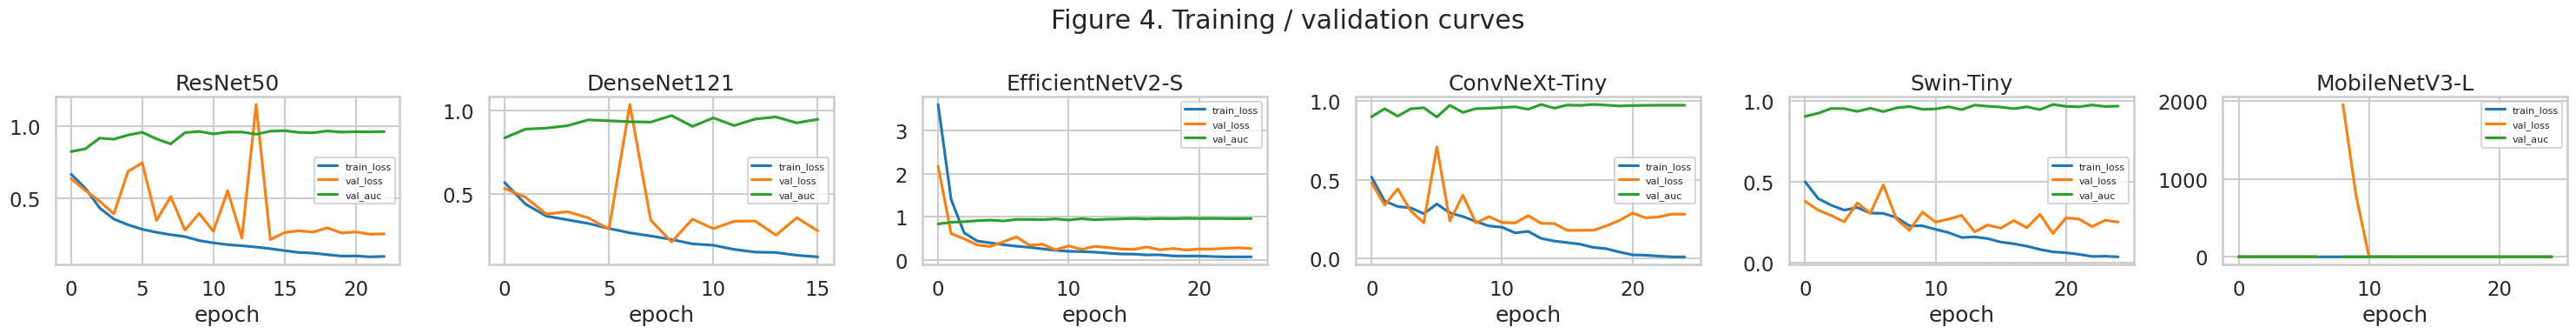

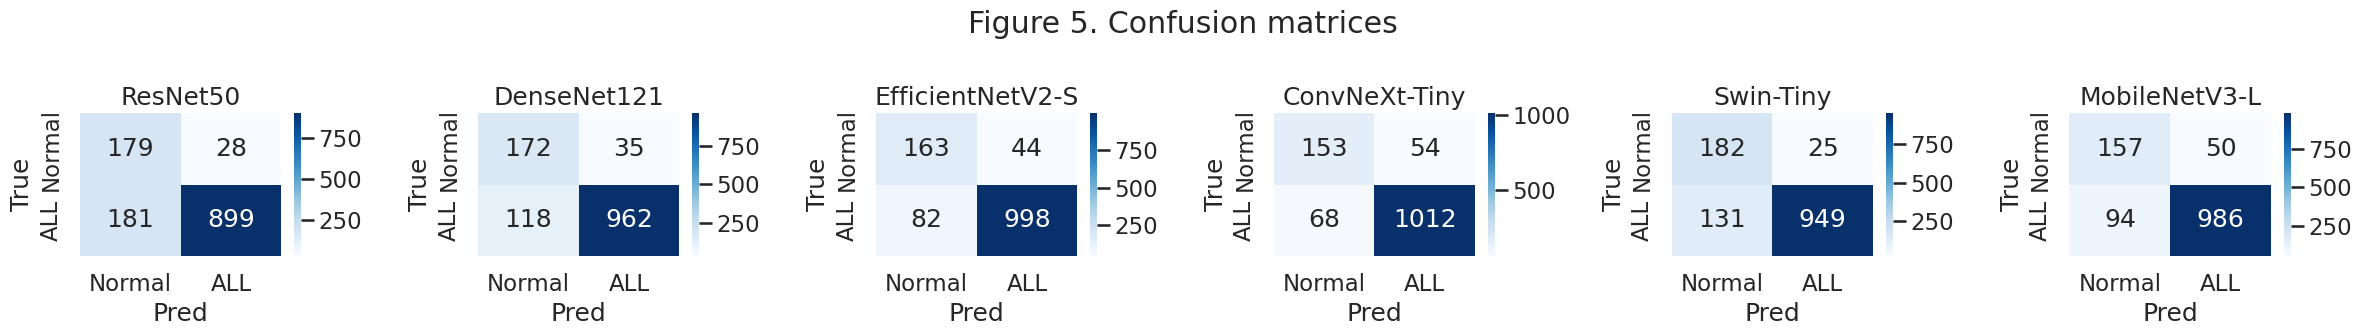

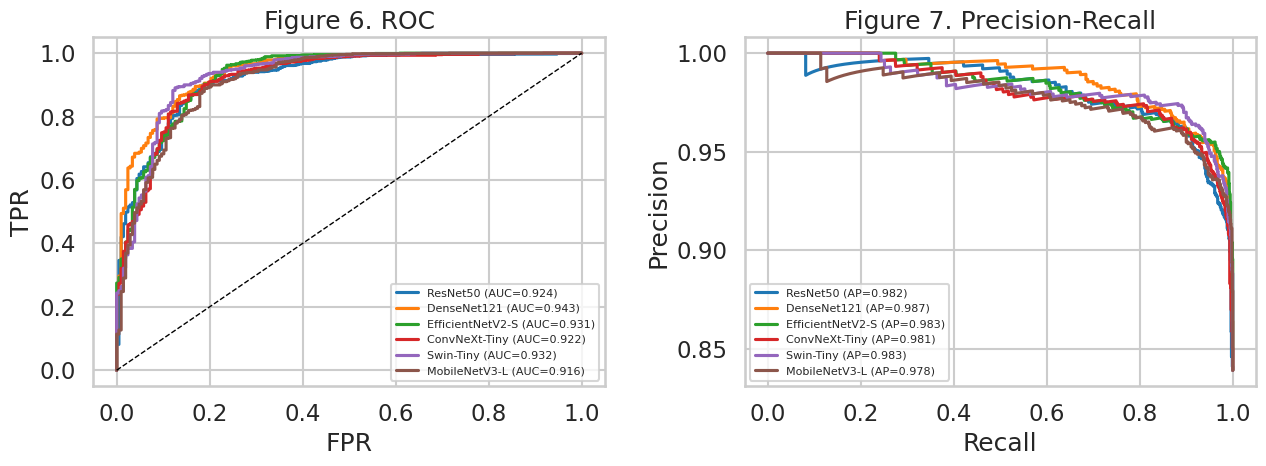

In [32]:
# Figure 4: training/validation curves
n=len(RESULTS); fig,axs=plt.subplots(1,n,figsize=(5*n,4),squeeze=False)
for ax,(name,r) in zip(axs[0],RESULTS.items()):
    h=r["hist"]; ax.plot(h["train_loss"],label="train_loss")
    ax.plot(h["val_loss"],label="val_loss"); ax.plot(h["val_auc"],label="val_auc")
    ax.set_title(name); ax.set_xlabel("epoch"); ax.legend(fontsize=8)
fig.suptitle("Figure 4. Training / validation curves"); plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/fig4_curves.png",dpi=150); plt.show()

# Figure 5: confusion matrices
fig,axs=plt.subplots(1,n,figsize=(4*n,3.5),squeeze=False)
for ax,(name,r) in zip(axs[0],RESULTS.items()):
    cm=confusion_matrix(r["test_labels"], r["test_probs"].argmax(1))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",ax=ax,
                xticklabels=CONFIG["CLASS_NAMES"],yticklabels=CONFIG["CLASS_NAMES"])
    ax.set_title(name); ax.set_xlabel("Pred"); ax.set_ylabel("True")
fig.suptitle("Figure 5. Confusion matrices"); plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/fig5_confusion.png",dpi=150); plt.show()

# Figure 6 & 7: ROC and PR
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,5))
for name,r in RESULTS.items():
    y=r["test_labels"]; p=r["test_probs"][:,1]
    fpr,tpr,_=roc_curve(y,p); a1.plot(fpr,tpr,label=f"{name} (AUC={roc_auc_score(y,p):.3f})")
    pr,rc,_=precision_recall_curve(y,p); a2.plot(rc,pr,label=f"{name} (AP={average_precision_score(y,p):.3f})")
a1.plot([0,1],[0,1],"k--",lw=1); a1.set_title("Figure 6. ROC"); a1.set_xlabel("FPR"); a1.set_ylabel("TPR"); a1.legend(fontsize=8)
a2.set_title("Figure 7. Precision-Recall"); a2.set_xlabel("Recall"); a2.set_ylabel("Precision"); a2.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{CONFIG['OUTPUT_DIR']}/fig6_7_roc_pr.png",dpi=150); plt.show()

## 15. Explainability — Grad-CAM (Figure 8)
Visual sanity check: the model should attend to **nucleus / cytoplasm / cell morphology**, not
background, staining artefacts, borders or scanner noise.

Target layers are chosen per architecture; transformer layers need a `reshape_transform`. These are
**timm-version sensitive** — if a model fails, the cell prints a warning and skips it (adjust the
target layer / reshape for your timm version).

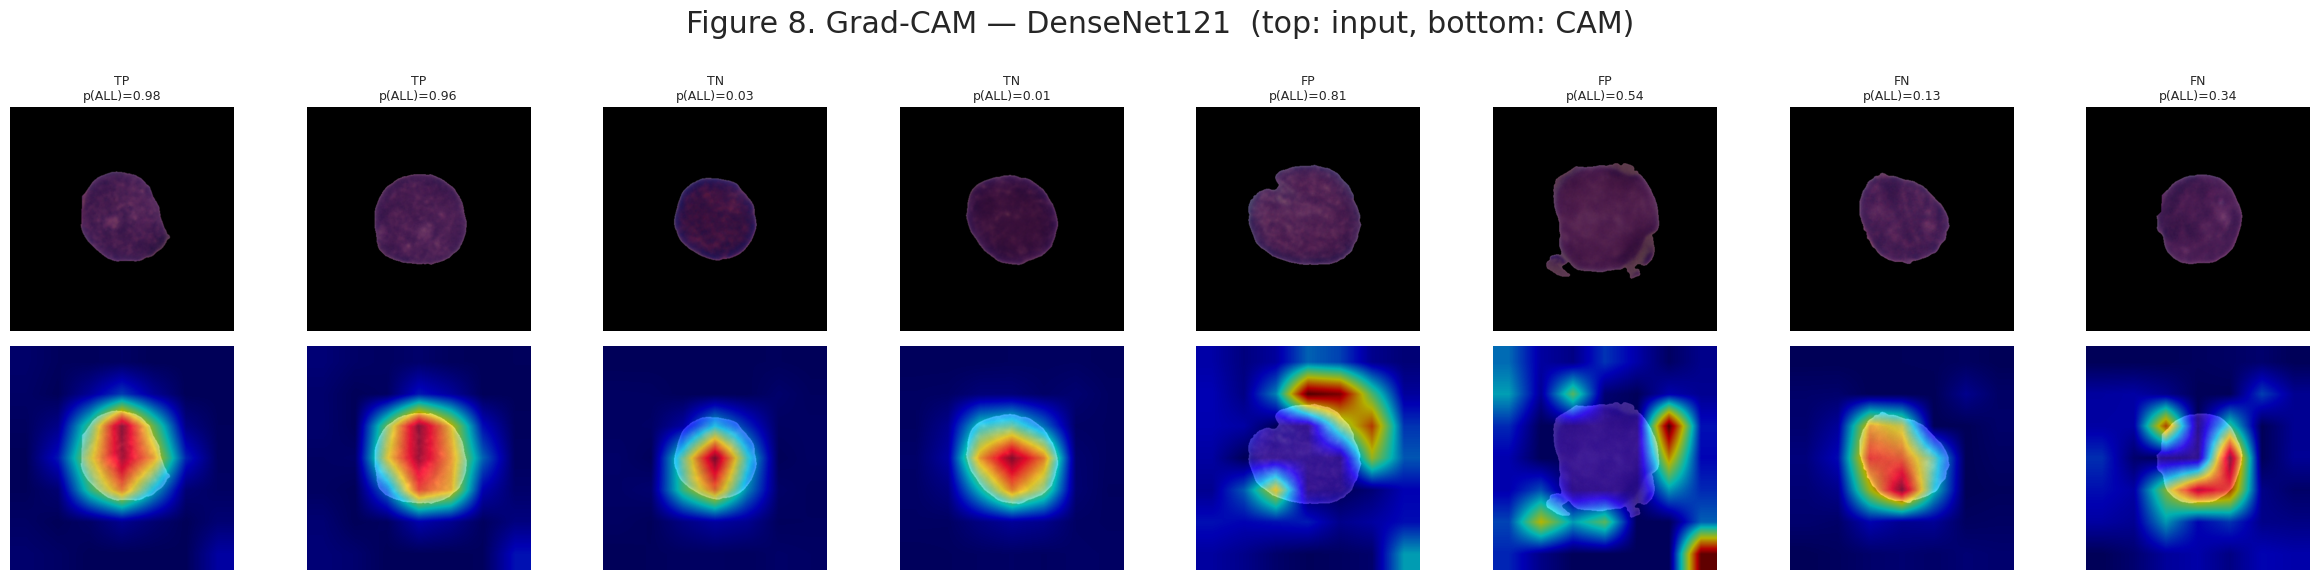

In [33]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def find_last_conv(model):
    last=None
    for m in model.modules():
        if isinstance(m, nn.Conv2d): last=m
    return last

def swin_reshape(t):
    # timm swin token tensor -> (B, C, H, W). Handles (B,L,C) or (B,H,W,C).
    if t.dim()==3:
        B,L,C=t.shape; s=int(L**0.5); t=t.reshape(B,s,s,C)
    return t.permute(0,3,1,2)

def cam_layers_for(model, name):
    name=name.lower(); reshape=None
    try:
        if "resnet" in name:               layers=[model.layer4[-1]]
        elif "densenet" in name:           layers=[model.features[-1]]
        elif "efficientnet" in name:       layers=[model.conv_head if hasattr(model,"conv_head") else find_last_conv(model)]
        elif "convnext" in name:           layers=[model.stages[-1].blocks[-1]]
        elif "mobilenet" in name:          layers=[find_last_conv(model)]
        elif "swin" in name:               layers=[model.layers[-1].blocks[-1].norm1]; reshape=swin_reshape
        else:                              layers=[find_last_conv(model)]
    except Exception:
        layers=[find_last_conv(model)]
    return layers, reshape

def denorm(t):
    m=torch.tensor(IMAGENET_MEAN).view(3,1,1); s=torch.tensor(IMAGENET_STD).view(3,1,1)
    return (t.cpu()*s+m).clamp(0,1).permute(1,2,0).numpy()

def gradcam_panel(name, n_each=2):
    r=RESULTS[name]; model=r["model"]; model.eval()
    layers, reshape = cam_layers_for(model, name)
    probs=r["test_probs"]; labels=r["test_labels"]; pred=probs.argmax(1)
    buckets={"TP":(labels==1)&(pred==1),"TN":(labels==0)&(pred==0),
             "FP":(labels==0)&(pred==1),"FN":(labels==1)&(pred==0)}
    try:
        cam=GradCAM(model=model, target_layers=layers, reshape_transform=reshape)
    except Exception as e:
        print(f"[{name}] Grad-CAM init failed: {e}"); return
    cols=[]
    for tag,mask in buckets.items():
        idxs=np.where(mask)[0][:n_each]
        for di in idxs: cols.append((tag,di))
    if not cols: print("No cases to show"); return
    fig,axs=plt.subplots(2,len(cols),figsize=(3*len(cols),6),squeeze=False)
    for j,(tag,di) in enumerate(cols):
        fp=test_df.iloc[di]["filepath"]
        img=Image.open(fp).convert("RGB").resize((SZ,SZ))
        x=eval_tf(img).unsqueeze(0).to(DEVICE)
        try:
            grayscale=cam(input_tensor=x, targets=[ClassifierOutputTarget(int(pred[di]))])[0]
            rgb=np.array(img).astype(np.float32)/255.0
            vis=show_cam_on_image(rgb, grayscale, use_rgb=True)
        except Exception as e:
            vis=np.array(img); print(f"[{name}] CAM failed on {tag}: {e}")
        axs[0,j].imshow(img); axs[0,j].set_title(f"{tag}\np(ALL)={probs[di,1]:.2f}",fontsize=9); axs[0,j].axis("off")
        axs[1,j].imshow(vis); axs[1,j].axis("off")
    fig.suptitle(f"Figure 8. Grad-CAM — {name}  (top: input, bottom: CAM)")
    plt.tight_layout(); plt.savefig(f"{CONFIG['OUTPUT_DIR']}/fig8_gradcam_{name}.png",dpi=150); plt.show()

gradcam_panel(BEST_MODEL)

## 16. Uncertainty estimation — TTA & MC-dropout (Figure 11)
TTA std and MC-dropout std quantify predictive uncertainty. We flag **high-confidence-correct**,
**high-confidence-wrong**, and **high-uncertainty** cases — clinically, high-uncertainty samples
should be triaged to expert haematologist review rather than auto-reported.

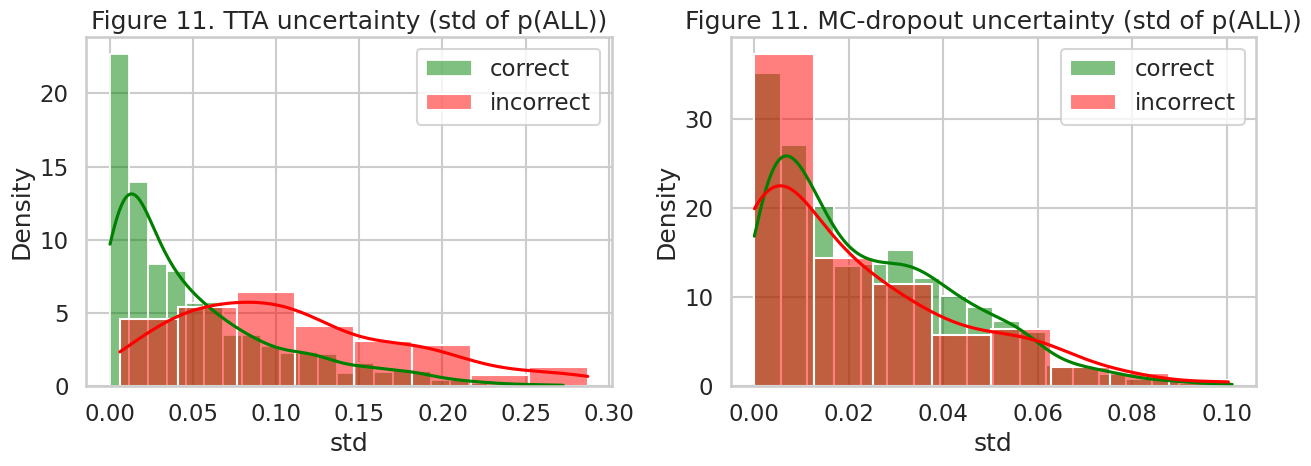

=== Uncertainty summary (best model) ===


,group,count,mean_tta_std
0,high-conf correct,627,0.0142
1,high-conf wrong,16,0.0231
2,high-uncertainty (top 10% TTA std),129,0.1826


In [34]:
def tta_uncertainty(model, frame, passes=None):
    passes=passes or CONFIG["TTA_PASSES"]; model.eval()
    loader=make_loader(frame, tta_tf, shuffle=False)
    acc=[]
    for _ in range(passes):
        p,_=collect_probs(model, loader); acc.append(p[:,1])
    arr=np.stack(acc,0)  # passes x N
    return arr.mean(0), arr.std(0)

def mc_dropout_uncertainty(model, frame, passes=None):
    passes=passes or CONFIG["MC_PASSES"]
    loader=make_loader(frame, eval_tf, shuffle=False)
    acc=[]
    for _ in range(passes):
        p,_=collect_probs(model, loader, mc_dropout=True); acc.append(p[:,1])
    arr=np.stack(acc,0)
    return arr.mean(0), arr.std(0)

r=RESULTS[BEST_MODEL]; model=r["model"]; labels=r["test_labels"]
tta_mean, tta_std = tta_uncertainty(model, test_df)
mc_mean,  mc_std  = mc_dropout_uncertainty(model, test_df)
pred = (tta_mean>=0.5).astype(int); correct = (pred==labels)

fig,axs=plt.subplots(1,2,figsize=(13,5))
for ax,(std,tag) in zip(axs,[(tta_std,"TTA"),(mc_std,"MC-dropout")]):
    sns.histplot(std[correct],color="green",label="correct",stat="density",kde=True,ax=ax,alpha=.5)
    sns.histplot(std[~correct],color="red",label="incorrect",stat="density",kde=True,ax=ax,alpha=.5)
    ax.set_title(f"Figure 11. {tag} uncertainty (std of p(ALL))"); ax.set_xlabel("std"); ax.legend()
plt.tight_layout(); plt.savefig(f"{CONFIG['OUTPUT_DIR']}/fig11_uncertainty.png",dpi=150); plt.show()

hi_unc = tta_std > np.quantile(tta_std, 0.9)
unc_table = pd.DataFrame({
    "group":["high-conf correct","high-conf wrong","high-uncertainty (top 10% TTA std)"],
    "count":[int(((tta_std<np.median(tta_std))&correct).sum()),
             int(((tta_std<np.median(tta_std))&~correct).sum()),
             int(hi_unc.sum())],
    "mean_tta_std":[round(float(tta_std[(tta_std<np.median(tta_std))&correct].mean()),4),
                    round(float(tta_std[(tta_std<np.median(tta_std))&~correct].mean() if (~correct&(tta_std<np.median(tta_std))).any() else np.nan),4),
                    round(float(tta_std[hi_unc].mean()),4)],
})
unc_table.to_csv(f"{CONFIG['OUTPUT_DIR']}/table5b_uncertainty.csv",index=False)
print("=== Uncertainty summary (best model) ==="); display(unc_table)

## 17. Calibration — reliability curve, ECE, temperature scaling (Figure 9)
A confident-but-wrong model is dangerous in screening. Temperature scaling rescales logits on the
**validation** set to fix over/under-confidence without changing accuracy.

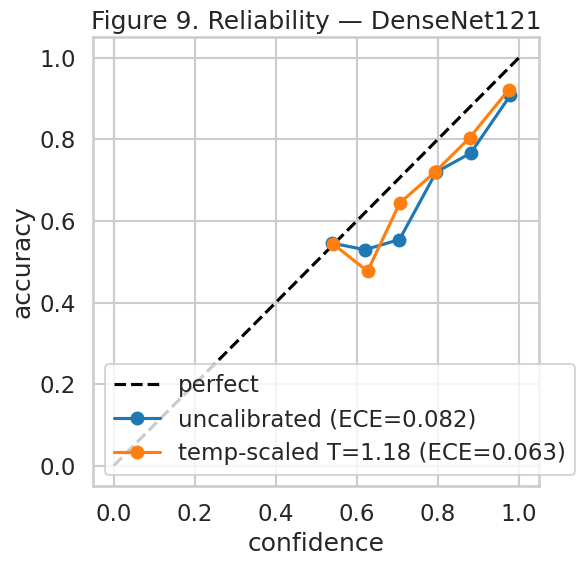

=== Table 5a. Calibration ===


,metric,uncalibrated,temp_scaled_T=1.18
0,ECE,0.0818,0.0632
1,Brier,0.1372,0.1343


In [35]:
@torch.no_grad()
def get_logits(model, loader):
    model.eval(); L=[]; Y=[]
    for x,y,_ in loader:
        x=x.to(DEVICE)
        with torch.amp.autocast("cuda", enabled=CONFIG["USE_AMP"]):
            L.append(model(x).float().cpu()); Y.append(y)
    return torch.cat(L), torch.cat(Y)

def fit_temperature(model, val_loader):
    logits, y = get_logits(model, val_loader)
    logits=logits.to(DEVICE); y=y.to(DEVICE)
    T=torch.nn.Parameter(torch.ones(1, device=DEVICE))
    opt=torch.optim.LBFGS([T], lr=0.01, max_iter=100)
    nll=nn.CrossEntropyLoss()
    def closure():
        opt.zero_grad(); loss=nll(logits/T, y); loss.backward(); return loss
    opt.step(closure)
    return float(T.detach().cpu())

def reliability_curve(probs, labels, n_bins=12, ax=None, label=""):
    conf=probs.max(1); pred=probs.argmax(1); acc=(pred==labels)
    bins=np.linspace(0,1,n_bins+1); xs=[]; ys=[]
    for lo,hi in zip(bins[:-1],bins[1:]):
        m=(conf>lo)&(conf<=hi)
        if m.sum()>0: xs.append(conf[m].mean()); ys.append(acc[m].mean())
    ax=ax or plt.gca(); ax.plot(xs,ys,marker="o",label=label)
    return ax

r=RESULTS[BEST_MODEL]; model=r["model"]
T = fit_temperature(model, val_loader)
test_logits, test_y = get_logits(model, test_loader)
probs_uncal = F.softmax(test_logits,1).numpy()
probs_cal   = F.softmax(test_logits/T,1).numpy()
test_y=test_y.numpy()

ece_pre=expected_calibration_error(probs_uncal,test_y)
ece_post=expected_calibration_error(probs_cal,test_y)
brier_pre=brier_score_loss(test_y,probs_uncal[:,1])
brier_post=brier_score_loss(test_y,probs_cal[:,1])

fig,ax=plt.subplots(figsize=(6,6))
ax.plot([0,1],[0,1],"k--",label="perfect")
reliability_curve(probs_uncal,test_y,ax=ax,label=f"uncalibrated (ECE={ece_pre:.3f})")
reliability_curve(probs_cal,test_y,ax=ax,label=f"temp-scaled T={T:.2f} (ECE={ece_post:.3f})")
ax.set_title(f"Figure 9. Reliability — {BEST_MODEL}"); ax.set_xlabel("confidence"); ax.set_ylabel("accuracy"); ax.legend()
plt.tight_layout(); plt.savefig(f"{CONFIG['OUTPUT_DIR']}/fig9_calibration.png",dpi=150); plt.show()

calib_table=pd.DataFrame({"metric":["ECE","Brier"],
                          "uncalibrated":[round(ece_pre,4),round(brier_pre,4)],
                          f"temp_scaled_T={T:.2f}":[round(ece_post,4),round(brier_post,4)]})
calib_table.to_csv(f"{CONFIG['OUTPUT_DIR']}/table5a_calibration.csv",index=False)
print("=== Table 5a. Calibration ==="); display(calib_table)

## 18. Failure analysis (Figure 10 + Table 6)
Gallery of FPs / FNs / high-confidence-wrong / high-uncertainty cases with likely causes
(poor staining, overlapping/clumped cells, blur, blast-like normals, uneven illumination,
cropped boundaries).

=== Table 6. Failure analysis ===


,case_type,count
0,false_positive,35
1,false_negative,118
2,high-confidence wrong (>0.9),16
3,high-uncertainty (top10% TTA),129


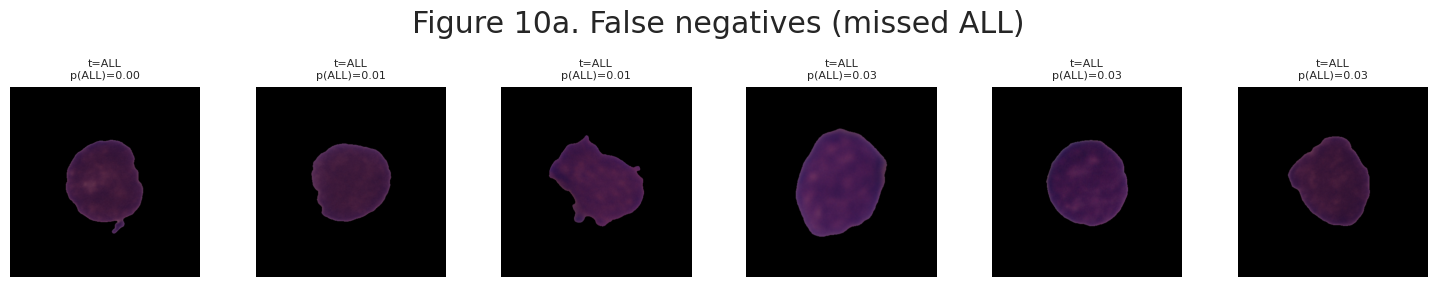

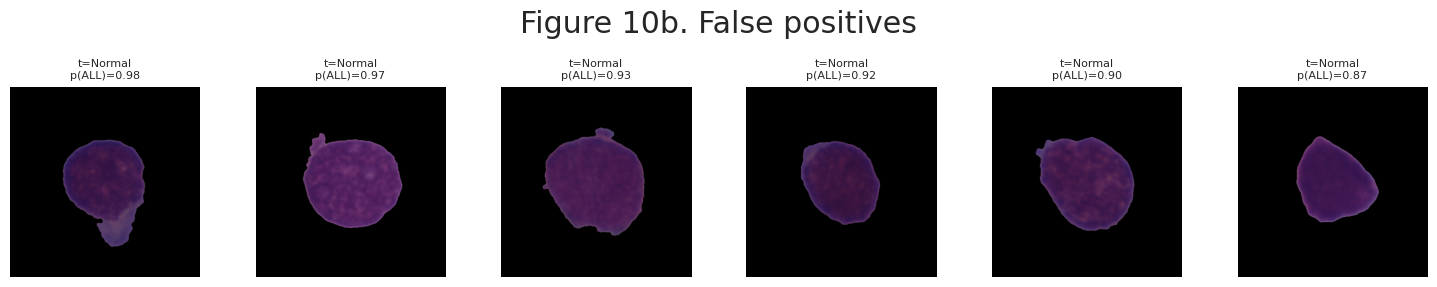

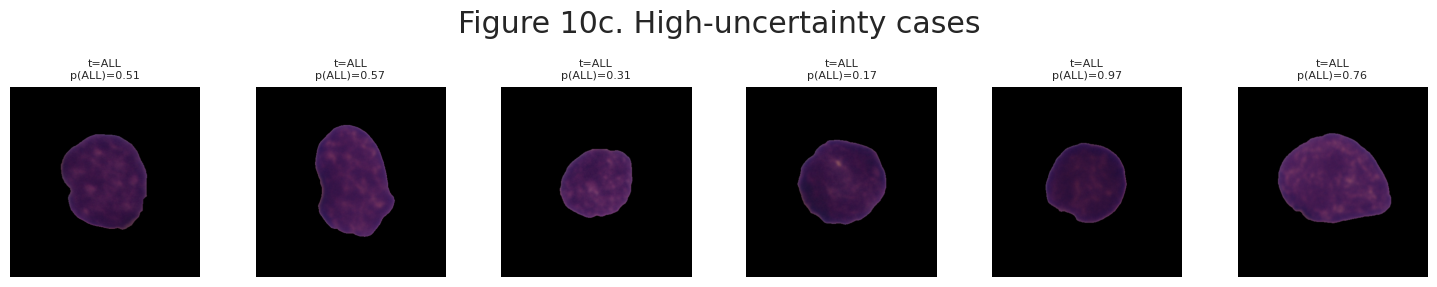

In [36]:
r=RESULTS[BEST_MODEL]; probs=r["test_probs"]; labels=r["test_labels"]; pred=probs.argmax(1)
fail_df=test_df.copy()
fail_df["p_all"]=probs[:,1]; fail_df["pred"]=pred; fail_df["true"]=labels
fail_df["tta_std"]=tta_std
fail_df["category"]=np.select(
    [(labels==0)&(pred==1),(labels==1)&(pred==0)],
    ["false_positive","false_negative"], default="correct")
fail_df["conf"]=probs.max(1)
fail_df["hc_wrong"]=(fail_df.category!="correct")&(fail_df.conf>0.9)
fail_df["high_uncertainty"]=fail_df["tta_std"]>np.quantile(tta_std,0.9)

table6=pd.DataFrame({
    "case_type":["false_positive","false_negative","high-confidence wrong (>0.9)","high-uncertainty (top10% TTA)"],
    "count":[int((fail_df.category=="false_positive").sum()),
             int((fail_df.category=="false_negative").sum()),
             int(fail_df.hc_wrong.sum()),
             int(fail_df.high_uncertainty.sum())],
})
table6.to_csv(f"{CONFIG['OUTPUT_DIR']}/table6_failure_analysis.csv",index=False)
print("=== Table 6. Failure analysis ==="); display(table6)

def fail_gallery(sub, title, k=6):
    sub=sub.head(k)
    if len(sub)==0: print("none in",title); return
    fig,axs=plt.subplots(1,len(sub),figsize=(2.5*len(sub),3))
    if len(sub)==1: axs=[axs]
    for ax,(_,row) in zip(axs,sub.iterrows()):
        ax.imshow(Image.open(row.filepath).convert("RGB"))
        ax.set_title(f"t={CONFIG['CLASS_NAMES'][int(row.true)]}\np(ALL)={row.p_all:.2f}",fontsize=8); ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

fail_gallery(fail_df[fail_df.category=="false_negative"].sort_values("p_all"),"Figure 10a. False negatives (missed ALL)")
fail_gallery(fail_df[fail_df.category=="false_positive"].sort_values("p_all",ascending=False),"Figure 10b. False positives")
fail_gallery(fail_df[fail_df.high_uncertainty].sort_values("tta_std",ascending=False),"Figure 10c. High-uncertainty cases")

## 19. Ablation study on the best model (Table 4)
Variants: no-aug, aug, weighted-CE, focal, + TTA at inference, + temperature calibration.
Each row is trained/evaluated under controlled conditions so the contribution of each component is
visible.

In [37]:
def evaluate_basic(model, loader):
    p,y=collect_probs(model,loader); return compute_metrics(p,y), p, y

ablation_rows={}

# baseline: no augmentation (eval_tf for training images)
noaug_loader=make_loader(train_df, eval_tf, shuffle=True)
m,_=train_model("ablate_noaug", CONFIG["ALL_MODELS"][BEST_MODEL], train_df, noaug_loader, val_loader,
                loss_kind="ce", verbose=False)
ablation_rows["no_aug + CE"]=evaluate_basic(m,test_loader)[0]; del m; gc.collect(); torch.cuda.empty_cache()

# augmentation + plain CE
m,_=train_model("ablate_aug_ce", CONFIG["ALL_MODELS"][BEST_MODEL], train_df, train_loader, val_loader,
                loss_kind="ce", verbose=False)
ablation_rows["aug + CE"]=evaluate_basic(m,test_loader)[0]; del m; gc.collect(); torch.cuda.empty_cache()

# augmentation + weighted CE
m,_=train_model("ablate_aug_wce", CONFIG["ALL_MODELS"][BEST_MODEL], train_df, train_loader, val_loader,
                loss_kind="weighted_ce", verbose=False)
ablation_rows["aug + weighted_CE"]=evaluate_basic(m,test_loader)[0]
best_for_tta=m  # reuse for TTA/calibration rows

# augmentation + focal
mf,_=train_model("ablate_aug_focal", CONFIG["ALL_MODELS"][BEST_MODEL], train_df, train_loader, val_loader,
                 loss_kind="focal", verbose=False)
ablation_rows["aug + focal"]=evaluate_basic(mf,test_loader)[0]; del mf; gc.collect(); torch.cuda.empty_cache()

# + TTA inference (on weighted_CE model)
tta_loader=make_loader(test_df, tta_tf, shuffle=False)
acc=[]
for _ in range(CONFIG["TTA_PASSES"]):
    p,yt=collect_probs(best_for_tta, tta_loader); acc.append(p)
p_tta=np.mean(acc,0)
ablation_rows["aug + weighted_CE + TTA"]=compute_metrics(p_tta, yt)

# + temperature calibration (metrics that change: ECE/Brier)
Tb=fit_temperature(best_for_tta, val_loader)
lg,yy=get_logits(best_for_tta,test_loader)
p_cal=F.softmax(lg/Tb,1).numpy()
ablation_rows["aug + weighted_CE + calibrated"]=compute_metrics(p_cal, yy.numpy())
del best_for_tta; gc.collect(); torch.cuda.empty_cache()

ablation_table=pd.DataFrame(ablation_rows).T.round(4)
ablation_table.to_csv(f"{CONFIG['OUTPUT_DIR']}/table4_ablation.csv")
print("=== Table 4. Ablation (best architecture =", BEST_MODEL, ") ==="); display(ablation_table)

=== Table 4. Ablation (best architecture = DenseNet121 ) ===


,accuracy,precision,sensitivity,specificity,f1,roc_auc,pr_auc,kappa,mcc,brier,ece
no_aug + CE,0.9075,0.9495,0.9398,0.7391,0.9446,0.9227,0.9812,0.6647,0.6650,0.0792,0.0699
aug + CE,0.8803,0.9548,0.9000,0.7778,0.9266,0.9189,0.9794,0.6046,0.6124,0.0843,0.0226
aug + weighted_CE,0.8889,0.9424,0.9241,0.7053,0.9331,0.8926,0.9732,0.6046,0.6056,0.0878,0.0477
aug + focal,0.8881,0.9634,0.9009,0.8213,0.9311,0.9337,0.9839,0.6353,0.6456,0.0959,0.1024
aug + weighted_CE + TTA,0.8850,0.9213,0.9435,0.5797,0.9323,0.8906,0.9736,0.5512,0.5529,0.0884,0.0514
aug + weighted_CE + calibrated,0.8889,0.9424,0.9241,0.7053,0.9331,0.8926,0.9732,0.6046,0.6056,0.0855,0.0288


## 20. Statistical analysis — bootstrap CIs & McNemar (Table 3 add-on)
Bootstrap 95% CIs for ROC-AUC and F1 of every model; McNemar test comparing the best model against
the strongest baseline (paired errors on the same test set).

In [38]:
from statsmodels.stats.contingency_tables import mcnemar

def bootstrap_ci(probs, labels, metric="auc", n=None, alpha=0.05):
    n=n or CONFIG["BOOTSTRAP_N"]; rng=np.random.default_rng(SEED)
    N=len(labels); vals=[]
    p1=probs[:,1]; pred=probs.argmax(1)
    for _ in range(n):
        idx=rng.integers(0,N,N)
        if len(np.unique(labels[idx]))<2: continue
        if metric=="auc": vals.append(roc_auc_score(labels[idx],p1[idx]))
        else: vals.append(f1_score(labels[idx],pred[idx],zero_division=0))
    lo,hi=np.percentile(vals,[100*alpha/2,100*(1-alpha/2)])
    return float(np.mean(vals)), float(lo), float(hi)

ci_rows={}
for name,r in RESULTS.items():
    a,al,ah=bootstrap_ci(r["test_probs"],r["test_labels"],"auc")
    f,fl,fh=bootstrap_ci(r["test_probs"],r["test_labels"],"f1")
    ci_rows[name]={"AUC":f"{a:.3f} [{al:.3f}, {ah:.3f}]","F1":f"{f:.3f} [{fl:.3f}, {fh:.3f}]"}
ci_table=pd.DataFrame(ci_rows).T
ci_table.to_csv(f"{CONFIG['OUTPUT_DIR']}/table3b_bootstrap_ci.csv")
print("=== 95% bootstrap CIs ==="); display(ci_table)

# McNemar: best vs strongest baseline
baselines=[m for m in ["ResNet50","DenseNet121","MobileNetV3-L"] if m in RESULTS and m!=BEST_MODEL]
if baselines:
    base=max(baselines, key=lambda m: RESULTS[m]["metrics"]["roc_auc"])
    yb=RESULTS[BEST_MODEL]["test_labels"]
    pb=RESULTS[BEST_MODEL]["test_probs"].argmax(1); pc=RESULTS[base]["test_probs"].argmax(1)
    cb=(pb==yb); cc=(pc==yb)
    tb=np.array([[np.sum(cb&cc), np.sum(cb&~cc)],[np.sum(~cb&cc), np.sum(~cb&~cc)]])
    res=mcnemar(tb, exact=False, correction=True)
    print(f"\nMcNemar {BEST_MODEL} vs {base}: statistic={res.statistic:.3f}, p-value={res.pvalue:.4f}")
    print("Significant at 0.05:", res.pvalue<0.05)

=== 95% bootstrap CIs ===


,AUC,F1
ResNet50,"0.924 [0.903, 0.943]","0.896 [0.881, 0.910]"
DenseNet121,"0.943 [0.925, 0.959]","0.926 [0.914, 0.938]"
EfficientNetV2-S,"0.931 [0.909, 0.951]","0.941 [0.930, 0.950]"
ConvNeXt-Tiny,"0.922 [0.899, 0.944]","0.943 [0.932, 0.953]"
Swin-Tiny,"0.932 [0.909, 0.953]","0.924 [0.912, 0.935]"
MobileNetV3-L,"0.916 [0.892, 0.939]","0.932 [0.920, 0.942]"



McNemar DenseNet121 vs ResNet50: statistic=16.440, p-value=0.0001
Significant at 0.05: True


## 21. Descriptive tables, save models & reproducibility checklist (Tables 1 & 2)

In [39]:
# Table 1. Dataset description
table1=pd.DataFrame({
    "split":["train","val","test","total"],
    "images":[len(train_df),len(val_df),len(test_df),len(df)],
    "ALL":[int((train_df.label==1).sum()),int((val_df.label==1).sum()),int((test_df.label==1).sum()),int((df.label==1).sum())],
    "Normal":[int((train_df.label==0).sum()),int((val_df.label==0).sum()),int((test_df.label==0).sum()),int((df.label==0).sum())],
    "patients":[train_df.patient_id.nunique(),val_df.patient_id.nunique(),test_df.patient_id.nunique(),df.patient_id.nunique()],
})
table1.to_csv(f"{CONFIG['OUTPUT_DIR']}/table1_dataset.csv",index=False)
print("=== Table 1. Dataset description ==="); display(table1)

# Table 2. Model configuration
table2=pd.DataFrame([{
    "model":n,"timm_id":CONFIG["ALL_MODELS"][n],
    "params_M":round(RESULTS[n]["metrics"]["params_M"],2),
    "size_MB":round(RESULTS[n]["metrics"]["size_MB"],1),
    "infer_ms":round(RESULTS[n]["metrics"]["infer_ms"],2),
} for n in RESULTS])
table2.to_csv(f"{CONFIG['OUTPUT_DIR']}/table2_model_config.csv",index=False)
print("=== Table 2. Model configuration / efficiency ==="); display(table2)

# Save best model weights
torch.save(RESULTS[BEST_MODEL]["model"].state_dict(),
           f"{CONFIG['OUTPUT_DIR']}/best_model_{BEST_MODEL}.pt")

checklist={
    "seed":SEED,"deterministic_cudnn":True,
    "split":"subject-level (grouped)" if HAS_PID else "image-level stratified (LIMITATION)",
    "patient_id_available":bool(HAS_PID),
    "duplicates_removed":True,"corrupt_removed":True,
    "external_validation":False,
    "torch":torch.__version__,"timm":timm.__version__,
    "img_size":SZ,"batch_size":CONFIG["BATCH_SIZE"],"epochs":CONFIG["EPOCHS"],
    "optimizer":"AdamW","scheduler":CONFIG["SCHEDULER"],"loss":CONFIG["LOSS"],
    "best_model":BEST_MODEL,"temperature":round(T,3),
    "models_run":CONFIG["MODELS_TO_RUN"],
}
with open(f"{CONFIG['OUTPUT_DIR']}/reproducibility_checklist.json","w") as fh:
    json.dump(checklist, fh, indent=2)
print("\n=== Reproducibility checklist ==="); print(json.dumps(checklist,indent=2))
print("\nAll tables/figures/models saved to:", CONFIG["OUTPUT_DIR"])

=== Table 1. Dataset description ===


,split,images,ALL,Normal,patients
0,train,7599,4977,2622,53
1,val,1087,774,313,11
2,test,1287,1080,207,9
3,total,9973,6831,3142,73


=== Table 2. Model configuration / efficiency ===


,model,timm_id,params_M,size_MB,infer_ms
0,ResNet50,resnet50,23.51,94.4,7.08
1,DenseNet121,densenet121,6.96,28.4,18.57
2,EfficientNetV2-S,tf_efficientnetv2_s,20.18,81.6,19.30
3,ConvNeXt-Tiny,convnext_tiny,27.82,111.4,6.46
4,Swin-Tiny,swin_tiny_patch4_window7_224,27.52,110.2,12.00
5,MobileNetV3-L,mobilenetv3_large_100,4.20,17.0,7.11



=== Reproducibility checklist ===
{
  "seed": 42,
  "deterministic_cudnn": true,
  "split": "subject-level (grouped)",
  "patient_id_available": true,
  "duplicates_removed": true,
  "corrupt_removed": true,
  "external_validation": false,
  "torch": "2.11.0+cu128",
  "timm": "1.0.27",
  "img_size": 224,
  "batch_size": 64,
  "epochs": 25,
  "optimizer": "AdamW",
  "scheduler": "onecycle",
  "loss": "weighted_ce",
  "best_model": "DenseNet121",
  "temperature": 1.176,
  "models_run": [
    "ResNet50",
    "DenseNet121",
    "EfficientNetV2-S",
    "ConvNeXt-Tiny",
    "Swin-Tiny",
    "MobileNetV3-L"
  ]
}

All tables/figures/models saved to: /content/drive/MyDrive/ALL_results


## 22. (Optional) 5-fold stratified-group cross-validation
Set `CONFIG["USE_CV"]=True` to run grouped 5-fold CV on the dev set (train+val) for the best
architecture, reporting mean +/- std AUC. The held-out **test** set is never touched here.

In [41]:
if CONFIG["USE_CV"]:
    dev_df = pd.concat([train_df, val_df]).reset_index(drop=True)
    sgkf = StratifiedGroupKFold(n_splits=CONFIG["CV_FOLDS"], shuffle=True, random_state=SEED)
    cv_aucs=[]
    for fold,(tr,va) in enumerate(sgkf.split(np.zeros(len(dev_df)), dev_df.label, dev_df.patient_id)):
        tr_df=dev_df.iloc[tr].reset_index(drop=True); va_df=dev_df.iloc[va].reset_index(drop=True)
        trl=make_loader(tr_df,train_tf,True); val=make_loader(va_df,eval_tf,False)
        m,_=train_model(f"cv{fold}", CONFIG["ALL_MODELS"][BEST_MODEL], tr_df, trl, val, verbose=False)
        p,y=collect_probs(m,val); auc=roc_auc_score(y,p[:,1]); cv_aucs.append(auc)
        print(f"Fold {fold}: AUC={auc:.4f}"); del m; gc.collect(); torch.cuda.empty_cache()
    print(f"\nCV AUC: {np.mean(cv_aucs):.4f} +/- {np.std(cv_aucs):.4f}")
    pd.DataFrame({"fold":range(len(cv_aucs)),"auc":cv_aucs}).to_csv(
        f"{CONFIG['OUTPUT_DIR']}/cv_results.csv",index=False)
else:
    print("CV disabled (CONFIG['USE_CV']=False).")

Fold 0: AUC=0.9961
Fold 1: AUC=0.9220
Fold 2: AUC=0.9793
Fold 3: AUC=0.9238
Fold 4: AUC=0.9302

CV AUC: 0.9503 +/- 0.0311


## 23. Suggested repository structure & paper mapping

```
all-detection/
  notebooks/ALL_detection.ipynb        # this notebook
  results/                             # CONFIG["OUTPUT_DIR"] contents
    table1_dataset.csv ... table6_failure_analysis.csv
    fig1_class_distribution.png ... fig11_uncertainty.png
    split_record.csv  reproducibility_checklist.json
    best_model_*.pt
  README.md  requirements.txt  LICENSE
```

**Figure -> notebook section:** Fig1/2 §7 · Fig3 (methodology, draw externally) · Fig4–7 §14 ·
Fig8 §15 · Fig9 §17 · Fig10 §18 · Fig11 §16.
**Table -> section:** T1/T2 §21 · T3 §13 (+CIs §20) · T4 §19 · T5 §16–17 · T6 §18 ·
T7 (comparison with prior work) fill from literature.

**Novelty (as framed):** a reproducible, leakage-aware, explainable, uncertainty-aware,
calibration-based *internal-validation* framework for ALL screening across modern CNN/ViT models —
**not** a first-ever-detector claim. **Key limitation:** single-source data, no external/multicentre
validation; report image-level splitting explicitly if patient IDs are unavailable.